In [5]:
pip install scikeras

In [6]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

Task 1: Dataset Exploration

In [2]:
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


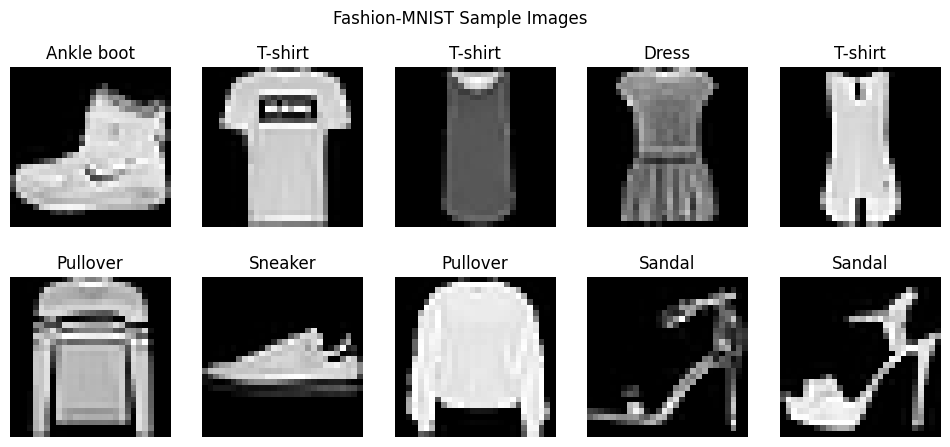

In [5]:
class_names = [
'T-shirt',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Fashion-MNIST Sample Images")

plt.savefig("Sample_Images.png", dpi=300, bbox_inches="tight")
plt.savefig("Sample_Images.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

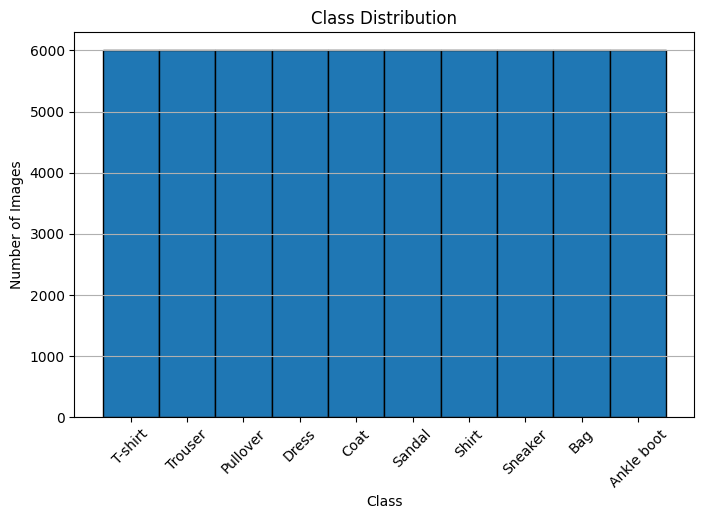

In [6]:
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=np.arange(11)-0.5, edgecolor='black')

plt.xticks(range(10), class_names, rotation=45)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.grid(axis='y')

plt.savefig("Class_Distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("Class_Distribution.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

Task 2: Data Preprocessing

In [7]:
print(x_train.shape)

(60000, 28, 28)


In [8]:
x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)

In [9]:
x_train = x_train/255.0
x_test = x_test/255.0

In [10]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [11]:
print("Tensor Shape before Preprocessing:")
print(x_train.shape)
print("Tensor Shape after Preprocessing:")
print(y_train_cat.shape)

Tensor Shape before Preprocessing:
(60000, 784)
Tensor Shape after Preprocessing:
(60000, 10)


Task 3: Model Construction

In [12]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Task 4: Training

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
history = model.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9854 - loss: 0.0417 - val_accuracy: 0.8813 - val_loss: 1.0476
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9844 - loss: 0.0433 - val_accuracy: 0.8874 - val_loss: 1.0694
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0366 - val_accuracy: 0.8910 - val_loss: 0.9873
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9849 - loss: 0.0424 - val_accuracy: 0.8895 - val_loss: 0.9677
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9842 - loss: 0.0489 - val_accuracy: 0.8896 - val_loss: 0.9220
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9874 - loss: 0.0357 - val_accuracy: 0.8852 - val_loss: 1.0356
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9846 - loss: 0.0408 - val_accuracy: 0.8912 - val_loss: 1.0182
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0388 -

Task 5: Evaluation

In [71]:
pred = model.predict(x_test)

pred_classes = np.argmax(pred,axis=1)
true_classes = np.argmax(y_test_cat,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [72]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:",
      accuracy_score(true_classes,pred_classes))

print(classification_report(
      true_classes,
      pred_classes))

Accuracy: 0.8797
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      1000
           1       0.99      0.97      0.98      1000
           2       0.79      0.79      0.79      1000
           3       0.89      0.89      0.89      1000
           4       0.81      0.78      0.80      1000
           5       0.98      0.96      0.97      1000
           6       0.65      0.76      0.70      1000
           7       0.94      0.96      0.95      1000
           8       0.98      0.96      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



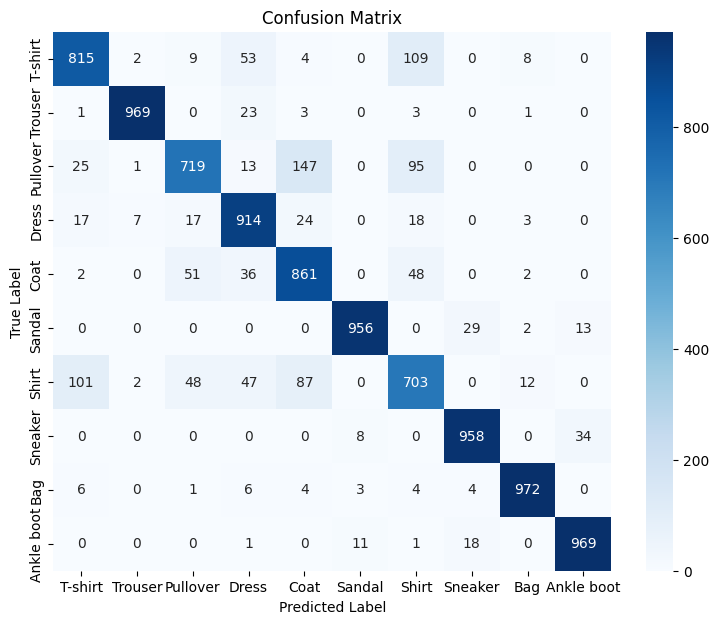

In [21]:
import seaborn as sns

cm = confusion_matrix(true_classes,pred_classes)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.savefig("Confusion_Matrix.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

Task 6: Hyperparameter Optimization

In [22]:
def create_model(hidden_layers=2,
                 hidden_neurons=128,
                 activation='relu',
                 optimizer='adam',
                 learning_rate=0.001,
                 dropout_rate=0.0):

    model = Sequential()
    model.add(Dense(hidden_neurons,
                    activation=activation,
                    input_shape=(784,)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers-1):
        model.add(Dense(hidden_neurons,
                        activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)

    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [23]:
clf = KerasClassifier(model=create_model)

In [24]:
param_dist = {
    "model__hidden_layers": [1,2,3],
    "model__hidden_neurons": [32,64,128,256],
    "model__learning_rate": [0.1,0.01,0.001],
    "model__activation": ["relu","tanh","sigmoid"],
    "model__optimizer": ["adam","sgd","rmsprop"],
    "model__dropout_rate": [0.0,0.2,0.5],
    "batch_size": [16,32,64,128],
    "epochs": [10,20,30]
}

In [25]:
search = RandomizedSearchCV(
    clf,
    param_dist,
    cv=5,
    n_iter=10,
    error_score="raise",
    verbose=2
)

search.fit(x_train,y_train_cat)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6145 - loss: 1.2846
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6620 - loss: 1.2396
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6939 - loss: 1.1153
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6898 - loss: 1.1238
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7088 - loss: 1.0977
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7226 - loss: 1.0604
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7253 - loss: 1.0515
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7258 - loss: 1.0443
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7358 - loss: 1.0253
Epoch 10/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7454 - loss: 1.0275
Epoch 11/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7470 - loss: 1.0265
Epoch 12/30
1500/1500 ━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6245 - loss: 1.1087
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7029 - loss: 0.9666
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7216 - loss: 0.9282
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7332 - loss: 0.8997
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7454 - loss: 0.8440
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7508 - loss: 0.8340
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7378 - loss: 0.8734
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7579 - loss: 0.8271
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7629 - loss: 0.8111
Epoch 10/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7637 - loss: 0.8174
Epoch 11/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7701 - loss: 0.8010
Epoch 12/30
1500/1500 ━━━━━━━━

...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2976 - loss: 2.6470
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2708 - loss: 1.9657
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3131 - loss: 1.8646
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3840 - loss: 1.6542
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3999 - loss: 1.6433
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4048 - loss: 1.6084
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4042 - loss: 1.6038
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4073 - loss: 1.6082
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4097 - loss: 1.6096
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4131 - loss: 1.5839
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4080 - loss: 1.5649
Epoch 12/20
1500/1500 ━━━━━━━━

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4965 - loss: 1.5666
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6794 - loss: 0.9948
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7191 - loss: 0.8386
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7399 - loss: 0.7633
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7557 - loss: 0.7138
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7679 - loss: 0.6769
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7766 - loss: 0.6502
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7832 - loss: 0.6286
Epoch 9/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7908 - loss: 0.6113
Epoch 10/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7941 - loss: 0.5950
Epoch 11/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7995 - loss: 0.5828
Epoch 12/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

RandomizedSearchCV(cv=5, error_score='raise',
                   estimator=KerasClassifier(model=<function create_model at 0x7a0f82d17f60>),
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']},
                   verbose=2)

In [26]:
import pandas as pd

results = pd.DataFrame(search.cv_results_)

In [27]:
print(search.best_params_)
print(search.best_score_)

{'model__optimizer': 'sgd', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 2, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 64}
0.83255


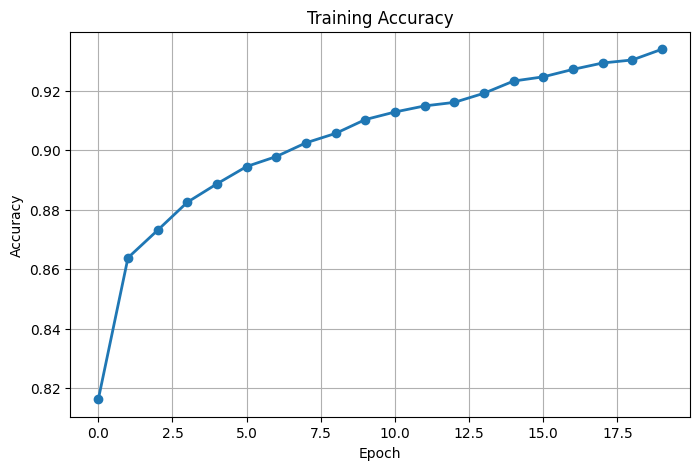

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],
         marker='o',
         linewidth=2)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.savefig("Training_Accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig("Training_Accuracy.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

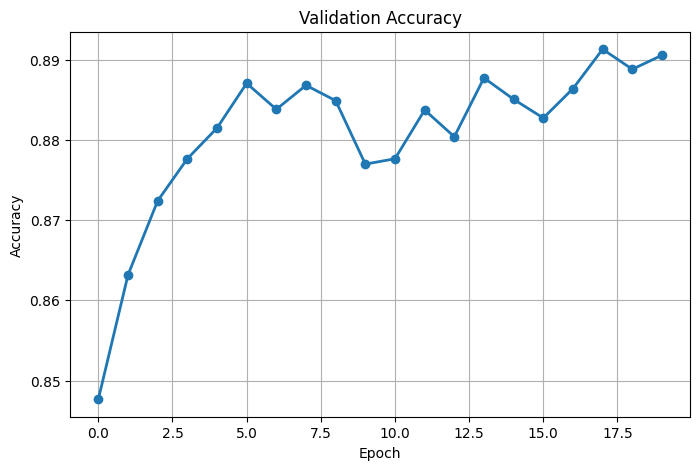

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_accuracy"],
         marker='o',
         linewidth=2)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.savefig("Validation_Accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig("Validation_Accuracy.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

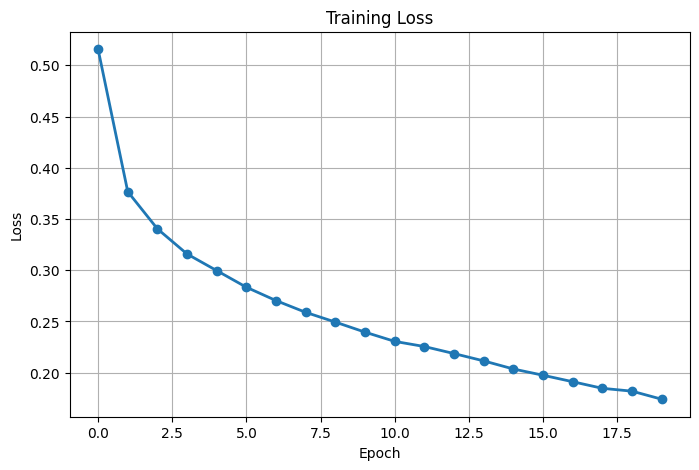

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],
         marker='o',
         linewidth=2)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig("Training_Loss.png", dpi=300, bbox_inches="tight")
plt.savefig("Training_Loss.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

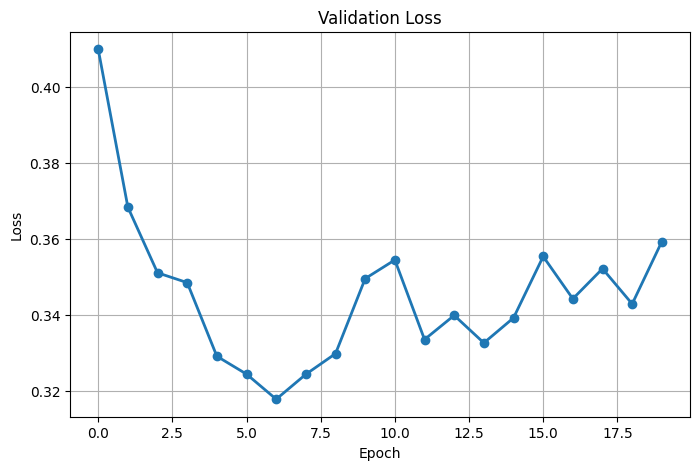

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_loss"],
         marker='o',
         linewidth=2)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig("Validation_Loss.png", dpi=300, bbox_inches="tight")
plt.savefig("Validation_Loss.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

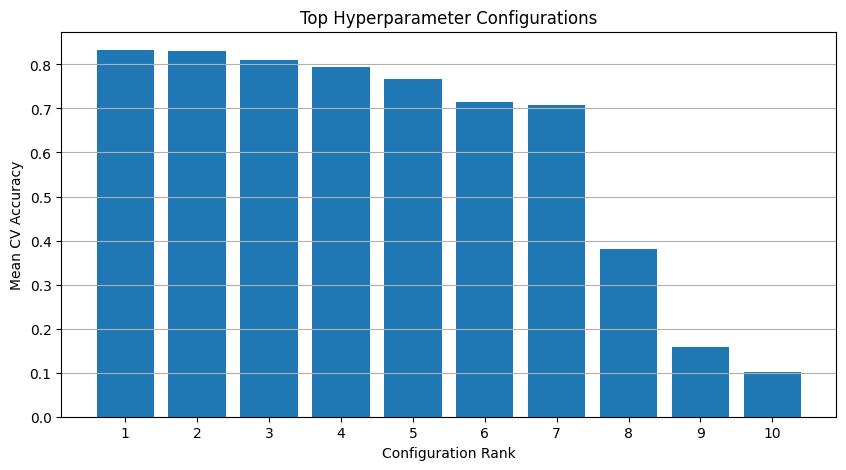

In [32]:
results = pd.DataFrame(search.cv_results_)

results = results.sort_values(
    "mean_test_score",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10,5))

plt.bar(
    range(1, len(results)+1),
    results["mean_test_score"]
)

plt.xticks(range(1, len(results)+1))

plt.xlabel("Configuration Rank")
plt.ylabel("Mean CV Accuracy")
plt.title("Top Hyperparameter Configurations")
plt.grid(axis="y")

plt.savefig(
    "Hyperparameter_Search.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Hyperparameter_Search.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [68]:
best_model = search.best_estimator_

optimized_prediction = best_model.predict(x_test)
optimized_prediction = np.argmax(
    optimized_prediction,
    axis=1
)

optimized_accuracy = accuracy_score(
    y_test,
    pred_classes
)

optimized_precision = precision_score(
    y_test,
    optimized_prediction,
    average="weighted"
)

optimized_recall = recall_score(
    y_test,
    optimized_prediction,
    average="weighted"
)

optimized_f1 = f1_score(
    y_test,
    optimized_prediction,
    average="weighted"
)

print("Optimized Model Performance")
print("----------------------------")
print(f"Accuracy : {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall   : {optimized_recall:.4f}")
print(f"F1-score : {optimized_f1:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Optimized Model Performance
----------------------------
Accuracy : 0.8881
Precision: 0.8272
Recall   : 0.8287
F1-score : 0.8275


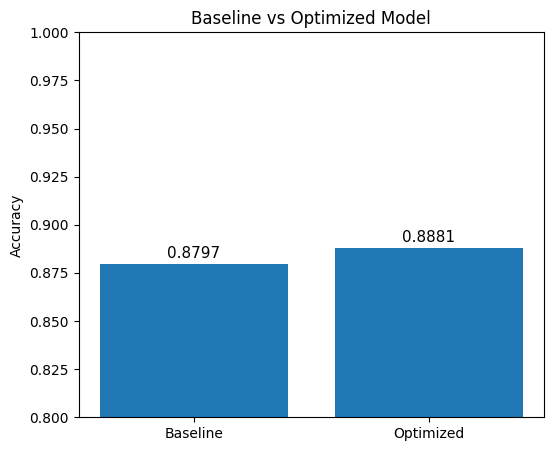

In [73]:
baseline_accuracy = accuracy_score(
    y_test,
    pred_classes
)

plt.figure(figsize=(6,5))

plt.bar(
    ["Baseline","Optimized"],
    [baseline_accuracy, optimized_accuracy]
)

plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Model")

plt.ylim(0.80,1.00)

for i, value in enumerate([baseline_accuracy, optimized_accuracy]):
    plt.text(
        i,
        value + 0.003,
        f"{value:.4f}",
        ha="center",
        fontsize=11
    )

plt.savefig(
    "Baseline_vs_Optimized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Baseline_vs_Optimized.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [74]:
results = pd.DataFrame(search.cv_results_)

print(results[[
    "mean_test_score",
    "rank_test_score",
    "params"
]])

   mean_test_score  rank_test_score  \
0         0.793217                4   
1         0.159017                9   
2         0.767767                5   
3         0.713617                6   
4         0.100817               10   
5         0.832550                1   
6         0.809083                3   
7         0.829500                2   
8         0.708100                7   
9         0.380433                8   

                                              params  
0  {'model__optimizer': 'rmsprop', 'model__learni...  
1  {'model__optimizer': 'rmsprop', 'model__learni...  
2  {'model__optimizer': 'sgd', 'model__learning_r...  
3  {'model__optimizer': 'sgd', 'model__learning_r...  
4  {'model__optimizer': 'rmsprop', 'model__learni...  
5  {'model__optimizer': 'sgd', 'model__learning_r...  
6  {'model__optimizer': 'sgd', 'model__learning_r...  
7  {'model__optimizer': 'rmsprop', 'model__learni...  
8  {'model__optimizer': 'rmsprop', 'model__learni...  
9  {'model__optimize

Additional Task: Perceptron Learning Algorithm for XOR Gate

In [36]:
class LogicPerceptron:

    def __init__(self, learning_rate=1, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs

    def activation(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        self.weight_history = []
        self.bias_history = []

        update = 1

        for epoch in range(self.epochs):

            error_count = 0

            for i in range(n_samples):

                output = np.dot(X[i], self.weights) + self.bias
                prediction = self.activation(output)

                error = y[i] - prediction

                if error != 0:

                    self.weights += self.lr * error * X[i]
                    self.bias += self.lr * error

                    self.weight_history.append(self.weights.copy())
                    self.bias_history.append(self.bias)

                    print(f"Update {update}")
                    print("Input :", X[i])
                    print("Target:", y[i])
                    print("Prediction:", prediction)
                    print("Weights:", self.weights)
                    print("Bias:", self.bias)
                    print("-"*40)

                    update += 1
                    error_count += 1

            if error_count == 0:
                break

    def predict(self, X):

        linear = np.dot(X, self.weights) + self.bias

        return np.array([self.activation(x) for x in linear])

In [37]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

In [38]:
xor_model = LogicPerceptron(
    learning_rate=1,
    epochs=10
)

xor_model.fit(X_xor, y_xor)

print("Final Weights:", xor_model.weights)
print("Final Bias:", xor_model.bias)

print("\nPredictions:")
print(xor_model.predict(X_xor))

Update 1
Input : [0 0]
Target: 0
Prediction: 1
Weights: [0. 0.]
Bias: -1
----------------------------------------
Update 2
Input : [0 1]
Target: 1
Prediction: 0
Weights: [0. 1.]
Bias: 0
----------------------------------------
Update 3
Input : [1 1]
Target: 0
Prediction: 1
Weights: [-1.  0.]
Bias: -1
----------------------------------------
Update 4
Input : [0 1]
Target: 1
Prediction: 0
Weights: [-1.  1.]
Bias: 0
----------------------------------------
Update 5
Input : [1 0]
Target: 1
Prediction: 0
Weights: [0. 1.]
Bias: 1
----------------------------------------
Update 6
Input : [1 1]
Target: 0
Prediction: 1
Weights: [-1.  0.]
Bias: 0
----------------------------------------
Update 7
Input : [0 0]
Target: 0
Prediction: 1
Weights: [-1.  0.]
Bias: -1
----------------------------------------
Update 8
Input : [0 1]
Target: 1
Prediction: 0
Weights: [-1.  1.]
Bias: 0
----------------------------------------
Update 9
Input : [1 0]
Target: 1
Prediction: 0
Weights: [0. 1.]
Bias: 1
-----------

In [39]:
import math

def plot_decision_boundaries(model, X, y, title):

    total = len(model.weight_history)

    cols = 3
    rows = math.ceil(total / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))

    if rows == 1 and cols == 1:
        axes = np.array([axes])

    axes = np.array(axes).flatten()

    for i in range(total):

        ax = axes[i]

        w = model.weight_history[i]
        b = model.bias_history[i]

        ax.scatter(
            X[:,0],
            X[:,1],
            c=y,
            cmap="bwr",
            s=120,
            edgecolors="k"
        )

        x_vals = np.linspace(-0.5, 1.5, 100)

        if abs(w[1]) > 1e-6:

            y_vals = -(w[0]*x_vals + b)/w[1]
            ax.plot(x_vals, y_vals, "k", linewidth=2)

        elif abs(w[0]) > 1e-6:

            ax.axvline(-b/w[0], color="k", linewidth=2)

        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)

        ax.set_title(f"Update {i+1}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.grid(True)

    for j in range(total, len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(
        "XOR_Gate.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        "XOR_Gate.eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()

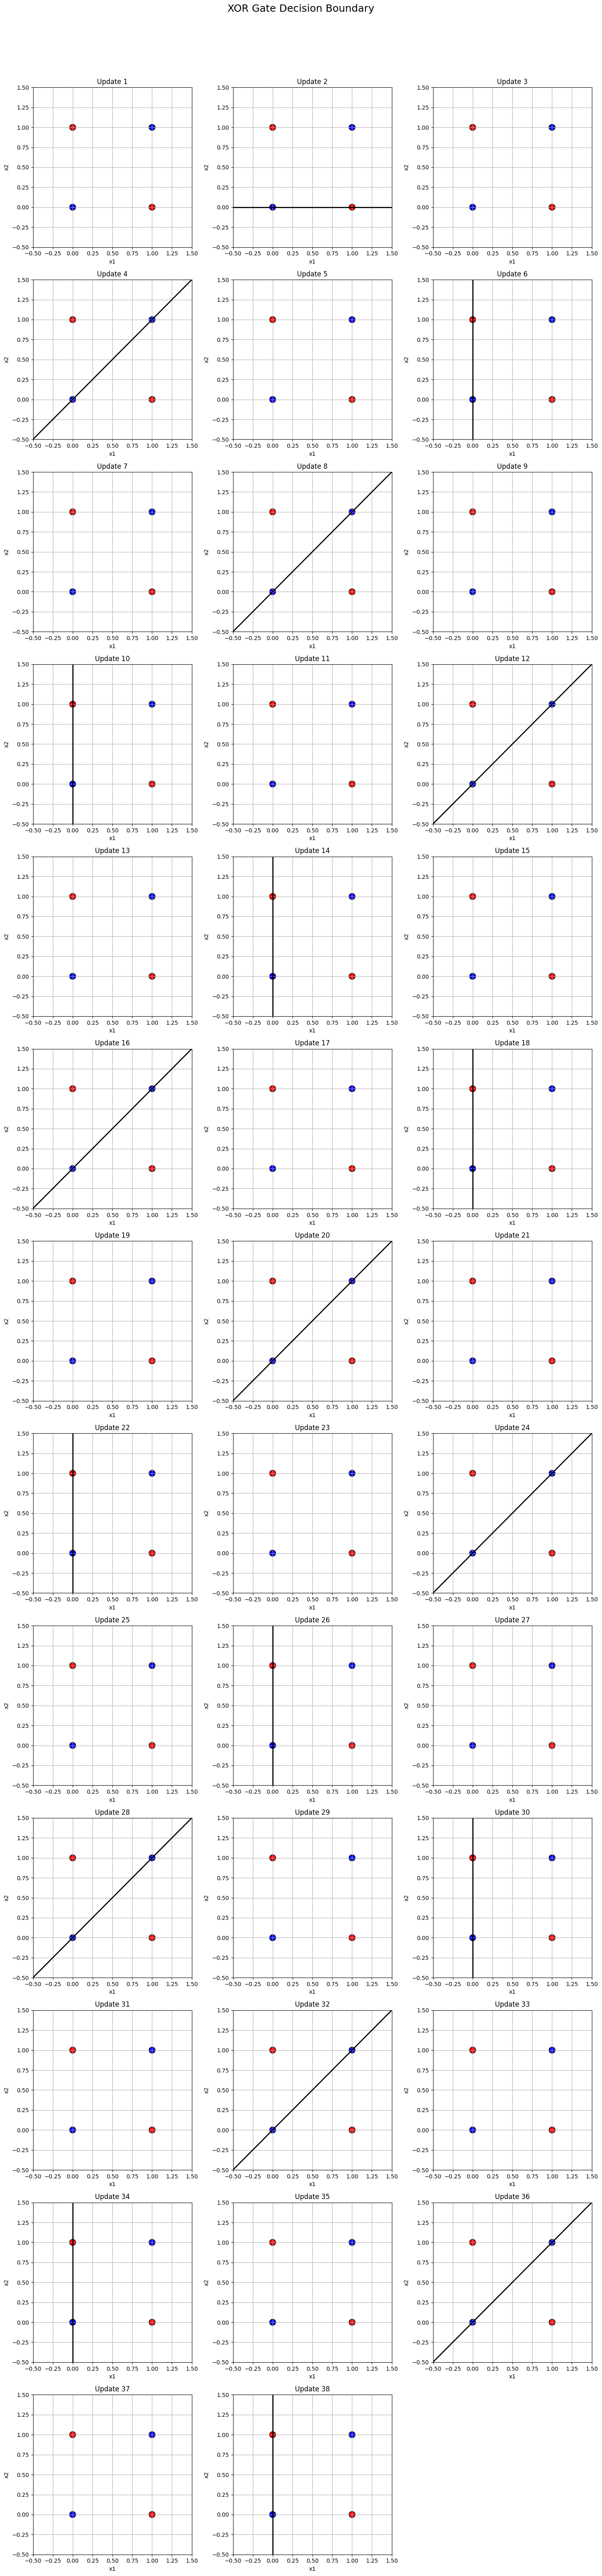

In [40]:
plot_decision_boundaries(
    xor_model,
    X_xor,
    y_xor,
    "XOR Gate Decision Boundary",
)

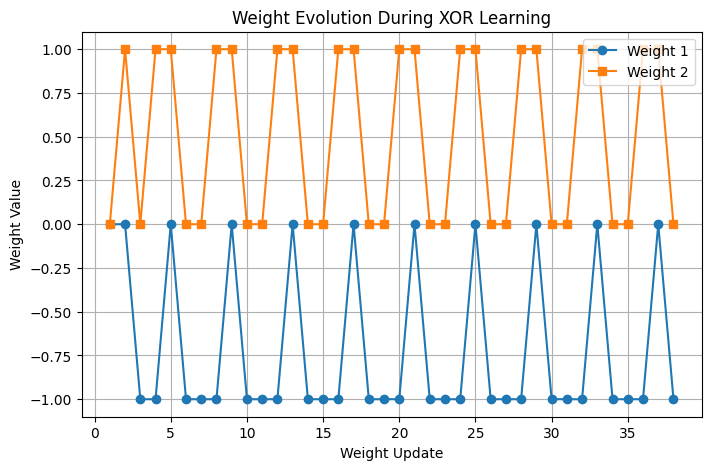

In [42]:
weights = np.array(xor_model.weight_history)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(weights)+1),
    weights[:,0],
    marker='o',
    label='Weight 1'
)

plt.plot(
    range(1, len(weights)+1),
    weights[:,1],
    marker='s',
    label='Weight 2'
)

plt.title("Weight Evolution During XOR Learning")
plt.xlabel("Weight Update")
plt.ylabel("Weight Value")
plt.legend()
plt.grid()

plt.savefig(
    "XOR_Weight_Evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "XOR_Weight_Evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [43]:
pred = xor_model.predict(X_xor)

print("Actual Labels     :", y_xor)
print("Predicted Labels  :", pred)

if np.array_equal(pred, y_xor):
    print("\nPerceptron Converged.")
else:
    print("\nPerceptron Did NOT Converge.")
    print("Reason: XOR is not linearly separable.")

Actual Labels     : [0 1 1 0]
Predicted Labels  : [1 1 0 0]

Perceptron Did NOT Converge.
Reason: XOR is not linearly separable.
